# Practice Exercise - Linear Regression

### Problem Statement

The problem at hand is to predict the housing prices of a town or a suburb based on the features of the locality provided to us. In the process, we need to identify the most important features in the dataset. We need to employ techniques of data preprocessing and build a linear regression model that predicts the prices for us. 

### Data Information

Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. Detailed attribute information can be found below-

Attribute Information (in order):
- CRIM: per capita crime rate by town
- ZN: proportion of residential land zoned for lots over 25,000 sq. ft.
- INDUS: proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX: nitric oxides concentration (parts per 10 million)
- RM: average number of rooms per dwelling
- AGE: proportion of owner-occupied units built prior to 1940
- DIS: weighted distances to five Boston employment centers
- RAD: index of accessibility to radial highways
- TAX: full-value property-tax rate per 10,000 dollars
- PTRATIO: pupil-teacher ratio by town
- LSTAT: %lower status of the population
- MEDV: Median value of owner-occupied homes in 1000 dollars.

### Import Necessary Libraries

In [11]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sn

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load the dataset

In [12]:
boston = pd.read_csv('Boston.csv')
data = boston.copy()

### Check the shape of the dataset

In [13]:
data.shape

(506, 13)

### Get the info regarding column datatypes

In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


### Get summary statistics for the numerical columns

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


### Exploratory Data Analysis

**Plot the distribution plots for all the numerical features and list your observations.**

In [16]:
print(data.isnull().sum())
print(data.duplicated().sum())


CRIM       0
ZN         0
INDUS      0
CHAS       0
NX         0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64
0


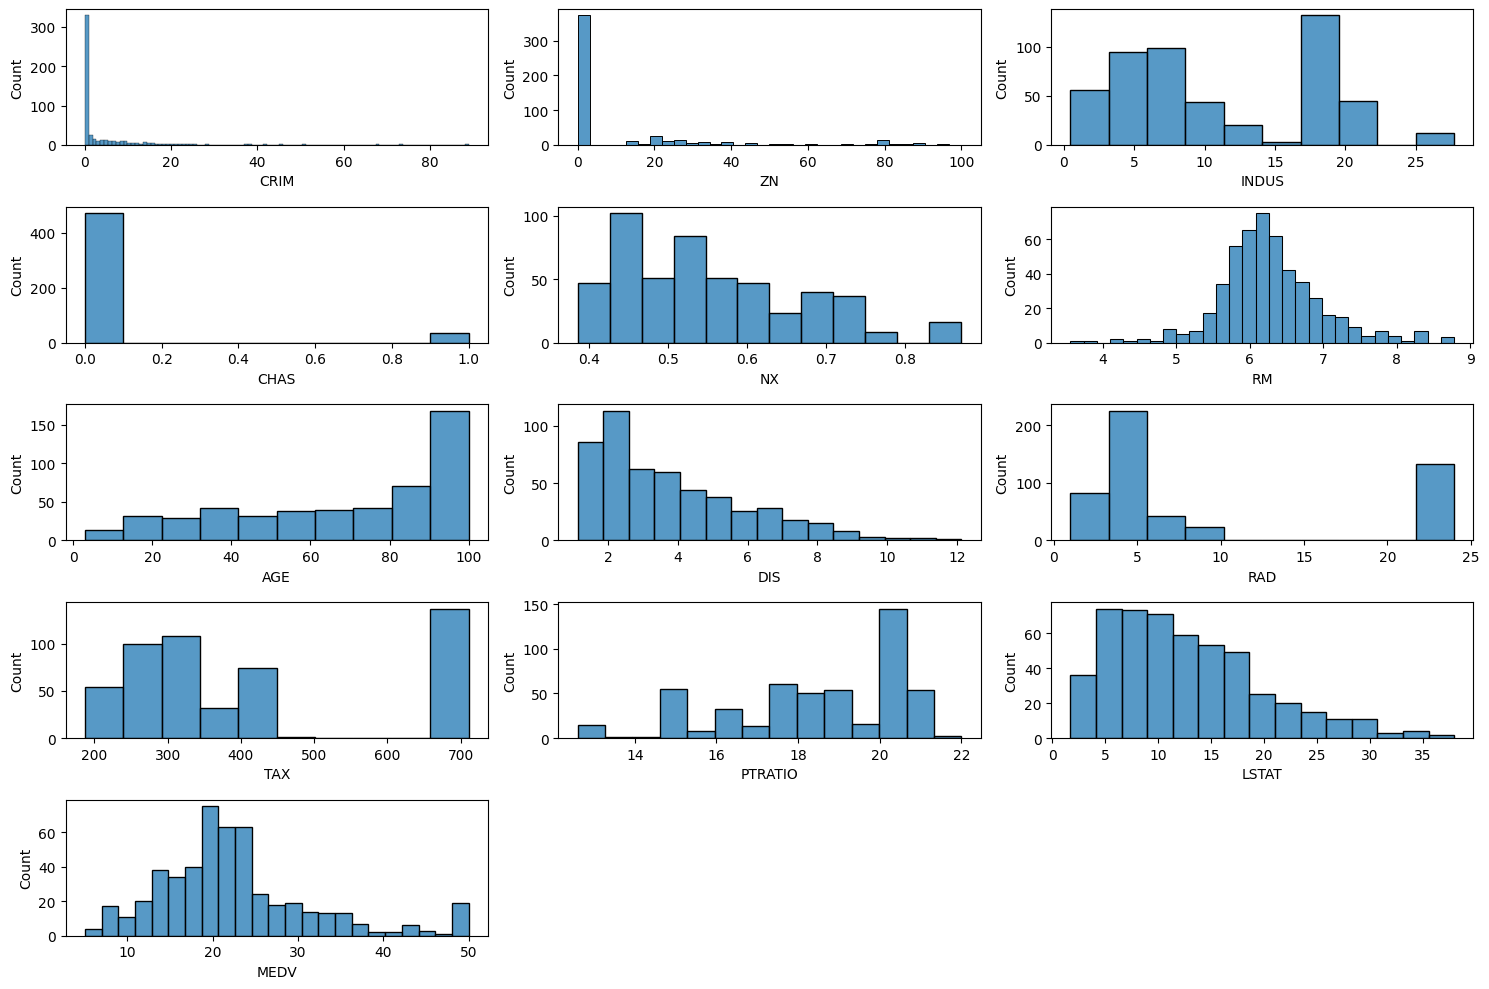

In [18]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data.select_dtypes(include=['number']).columns.tolist()
rows = int(len(features)/3)
# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(rows+1, 3, i+1)    # assign a subplot in the main plot
    sn.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

Right skewed - CRIM, MEDV, LSTAT, DIS, NX, ZN
Left skewed - PTRATIO, , AGE, 
Even - RM

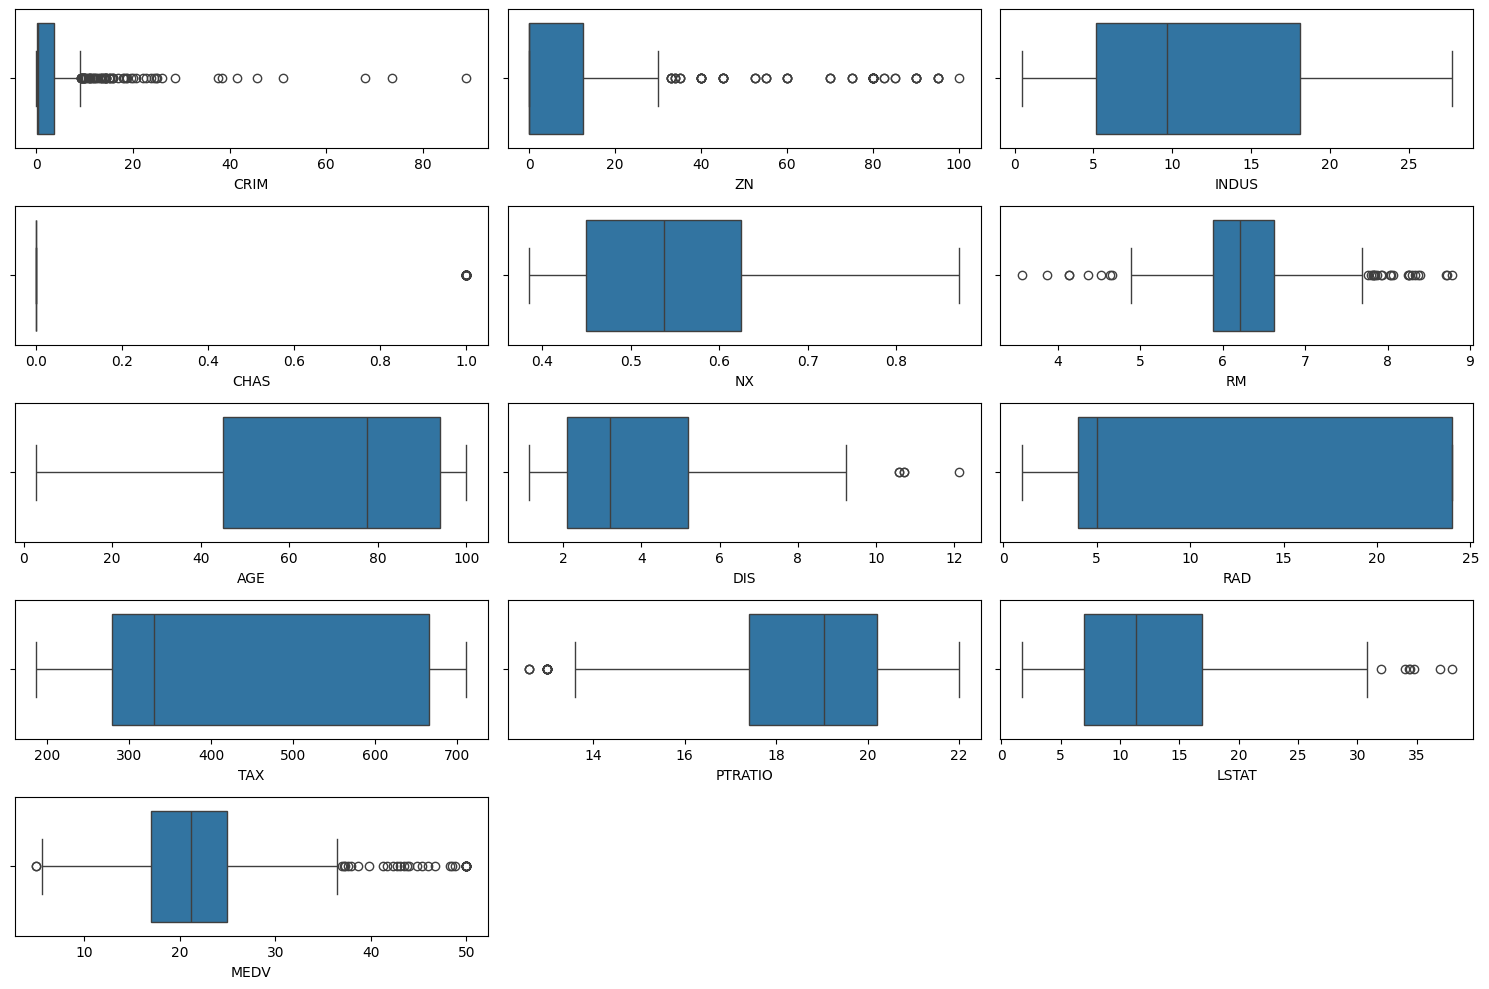

In [20]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data.select_dtypes(include=['number']).columns.tolist()
rows = int(len(features)/3)
# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(rows+1, 3, i+1)    # assign a subplot in the main plot
    sn.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

**Plot the scatterplots for features and the target variable `MEDV` and list your observations.**

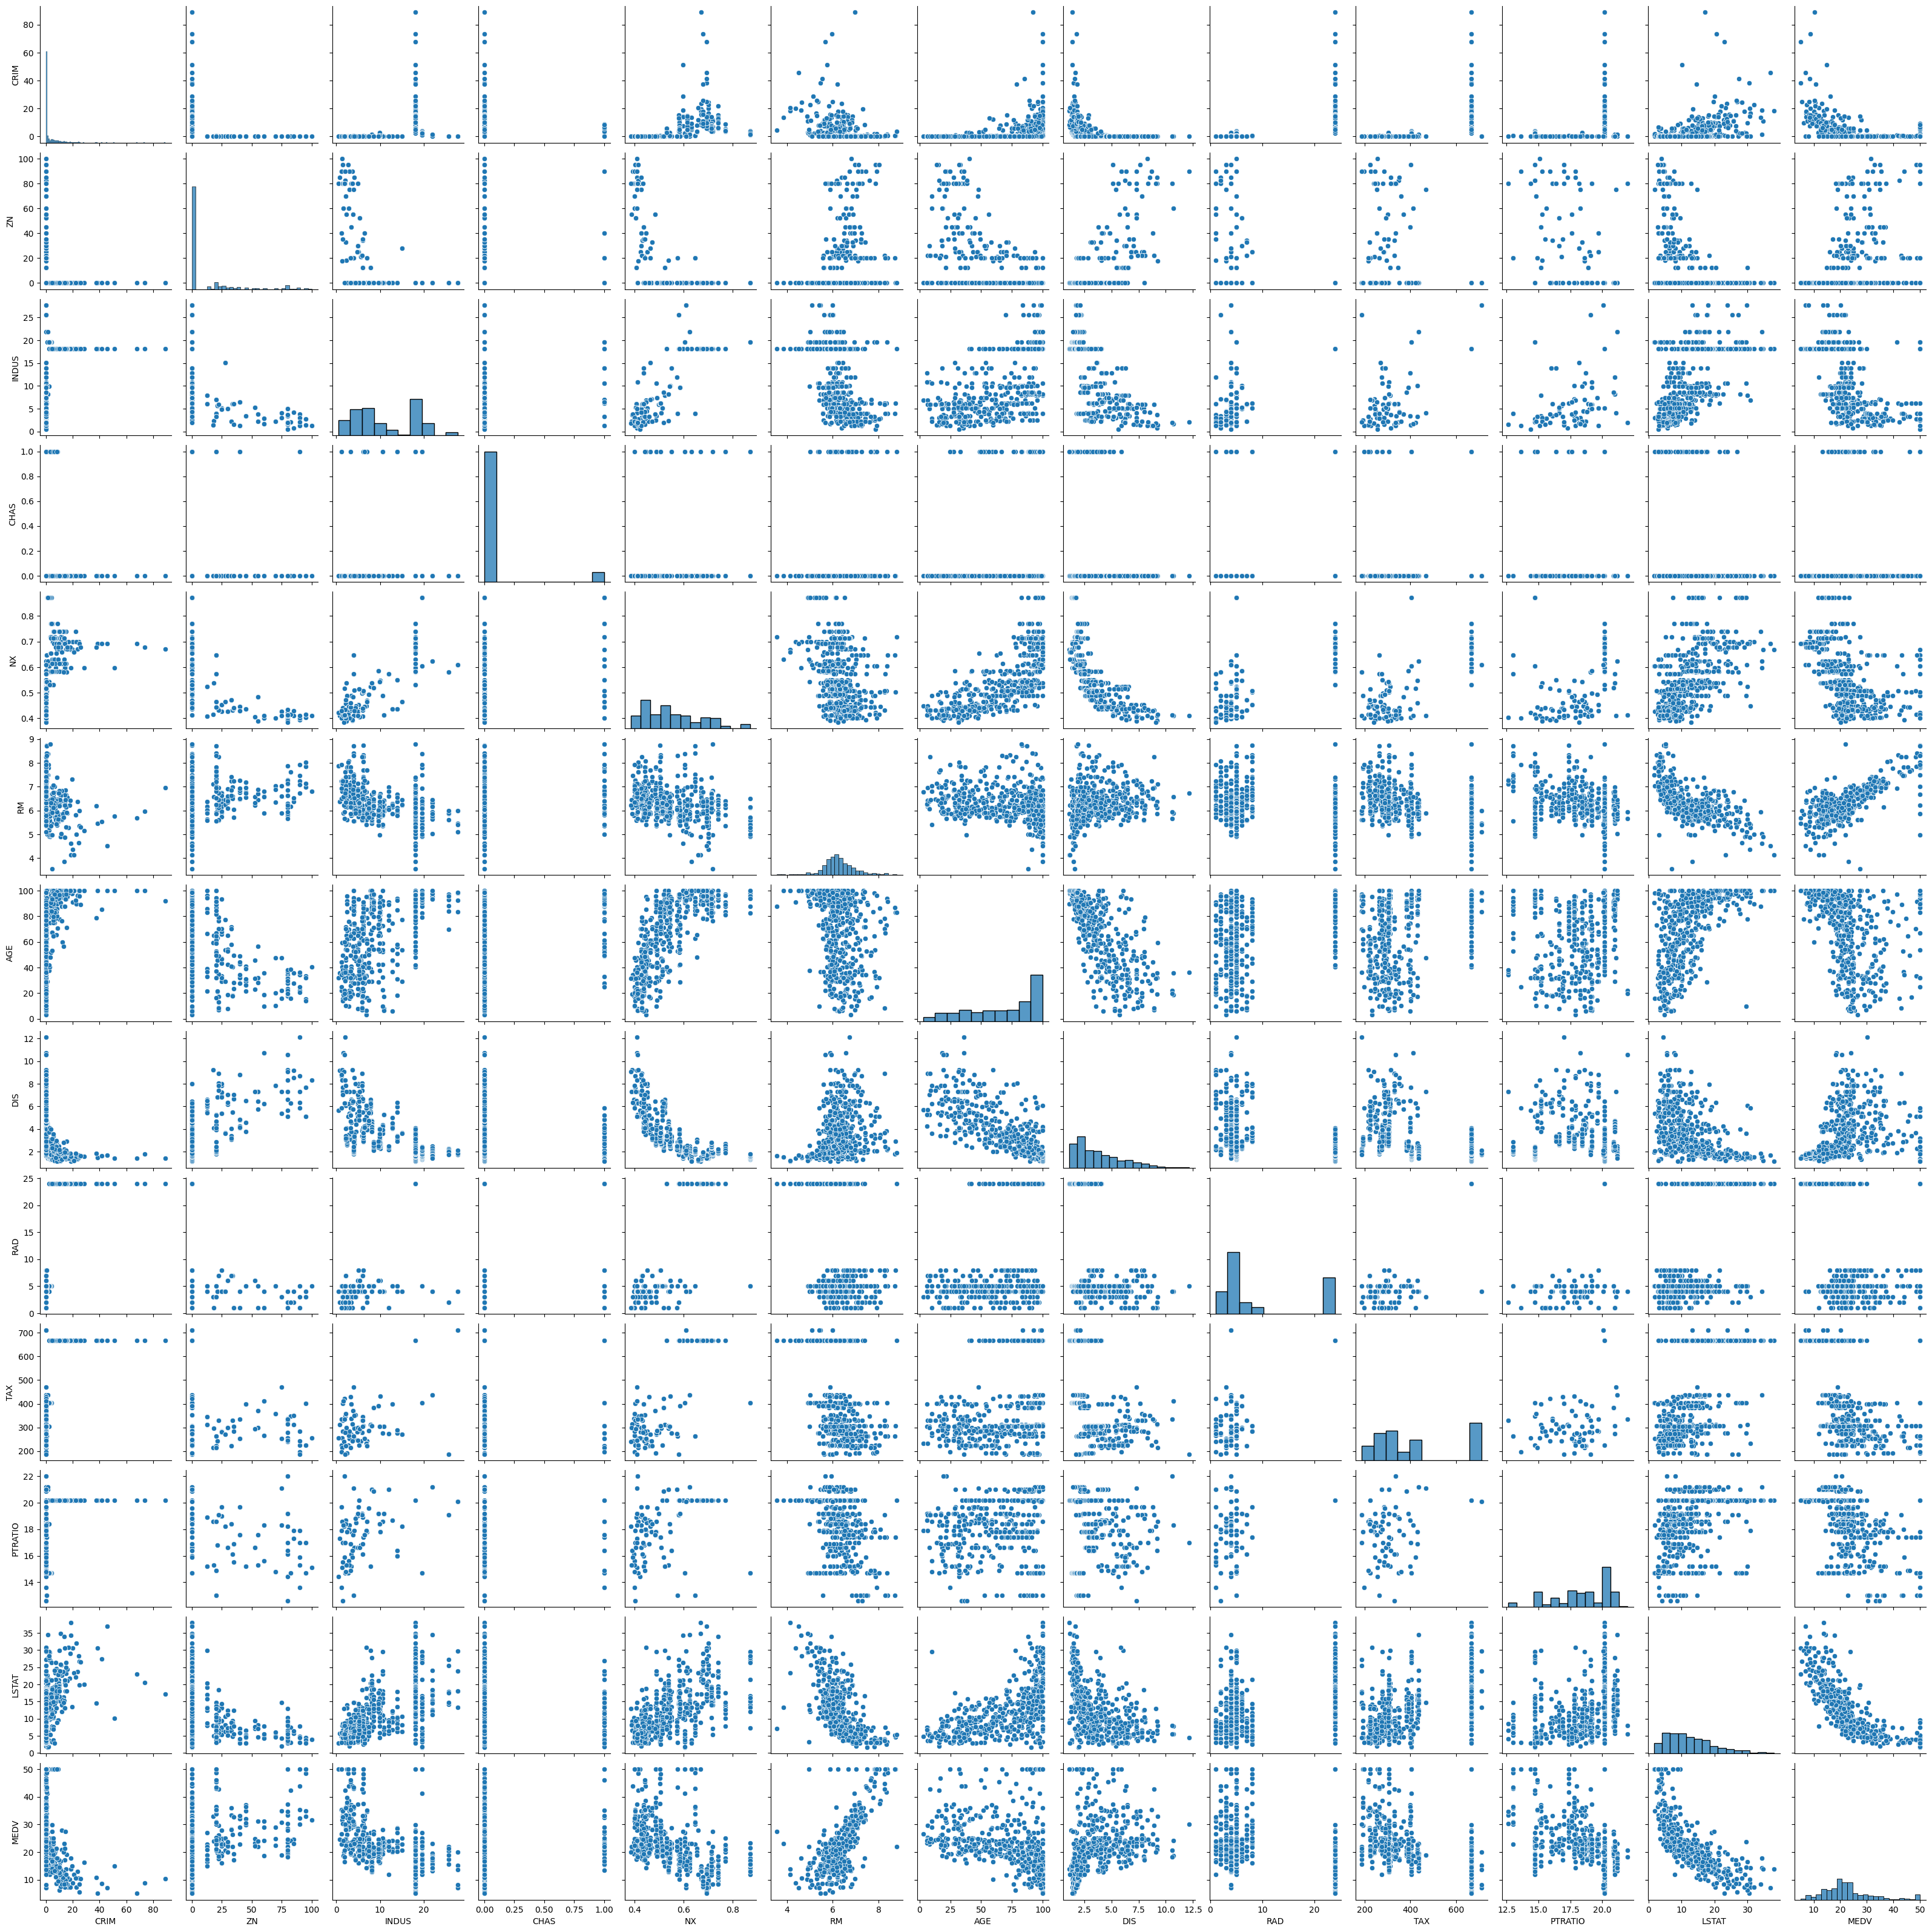

In [21]:
sn.pairplot(data=data)
plt.show()

**Plot the correlation heatmap and list your observations.**

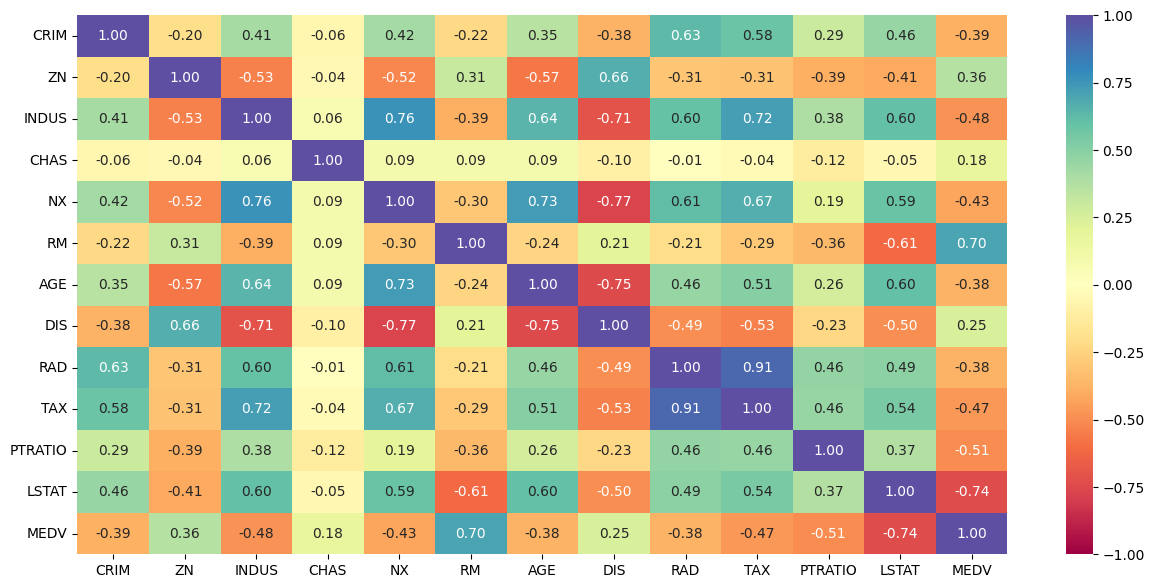

In [22]:
plt.figure(figsize=(15, 7))
sn.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### Split the dataset

Split the data into the dependent and independent variables, and further split it in a ratio of 70:30 for train and test sets.

In [23]:
X = data.drop(columns=['MEDV'], axis=1)
y = data['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
regressor = LinearRegression()




The score (R-squared) on the training set is  0.7340777261931664


### Model Building

**Fit the model to the training set**

In [24]:
regressor.fit(X_train, y_train)



LinearRegression()

**Get the score on training set**

In [25]:
print(
    "The score (R-squared) on the training set is ",
    regressor.score(X_train, y_train),
)

The score (R-squared) on the training set is  0.7340777261931664


**Write your own function for the R-squared score.**

In [27]:
# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regression model
    predictors: independent variables
    target: dependent variable
 
    RMSE (Root Mean Squared Error): 
        RMSE measures the square root of the average squared differences between actual 
        and predicted values, providing a metric that is in the same units as the target 
        variable and penalizes larger errors more heavily.
    MAPE (Mean Absolute Percentage Error): 
        MAPE calculates the average absolute percentage difference between actual and 
        predicted values, expressing prediction accuracy as a percentage and allowing 
        for easy interpretation across different scales.
    R² (Coefficient of Determination): 
        R² indicates the proportion of the variance in 
        the dependent variable that is predictable from the independent variables, with 
        values closer to 1 signifying a better fit.
    MAE (Mean Absolute Error): 
        MAE measures the average absolute difference between the actual and predicted 
        values, providing a straightforward metric of prediction accuracy.
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE
    r2 = r2_score(target, pred)  # to compute R-squared
    adj_r2 = adj_r2_score(predictors, target, pred)  # to compute Adjusted R-squared

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R-squared": r2,
            "Adj R-squared": adj_r2,
        },
        index=[0],
    )

    return df_perf



**Get the score on test set**

In [28]:
model_performance_regression(regressor, X_test, y_test)

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,4.595155,3.188662,16.755664,0.716621,0.692157


**Get the RMSE on test set**

**Get the model coefficients.**

In [29]:
print(regressor.coef_, " " , regressor.intercept_)

coef_df = pd.DataFrame(
    np.append(regressor.coef_, regressor.intercept_),
    index=X_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)

coef_df

[-1.39806261e-01  3.61191791e-02  3.62981883e-02  3.46492251e+00
 -1.59831769e+01  3.89980705e+00 -8.87065929e-03 -1.38856394e+00
  2.19830162e-01 -9.20022754e-03 -8.90506364e-01 -5.73644177e-01]   37.57987443867431


,Coefficients
CRIM,-0.139806
ZN,0.036119
INDUS,0.036298
CHAS,3.464923
NX,-15.983177
RM,3.899807
AGE,-0.008871
DIS,-1.388564
RAD,0.219830
TAX,-0.009200


**Automate the equation of the fit**

In [30]:
equation = ""
for i, col in enumerate(X.columns):
    equation = equation + (f" {col}  * {regressor.coef_[i]}  + \n\t")

print(f"{y.name} = {equation} {regressor.intercept_}", end="")

MEDV =  CRIM  * -0.13980626089381057  + 
	 ZN  * 0.0361191790842834  + 
	 INDUS  * 0.03629818831648595  + 
	 CHAS  * 3.4649225098626864  + 
	 NX  * -15.983176944901956  + 
	 RM  * 3.8998070508428313  + 
	 AGE  * -0.008870659291423198  + 
	 DIS  * -1.388563938897251  + 
	 RAD  * 0.21983016204780254  + 
	 TAX  * -0.009200227539670626  + 
	 PTRATIO  * -0.8905063641345756  + 
	 LSTAT  * -0.5736441765420527  + 
	 37.57987443867431